In [ ]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Paths
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR  # unmerge/unmerger
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..', '..'))  # PracticeTagging

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
import importlib
from model import OrderedUnmerger, TokenTagger, DualViewTagger  # noqa: E402

importlib.reload(tool)  # noqa: E402

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Experiment output
RUN_NAME = 'OrderedUnmerger_kpred'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 50000,
    'max_particles': 100,
    'pack_max_particles': 100,
    'hlt_effects': {
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        'efficiency_loss': 0.03,
    },
    'model': {
        'input_dim': 4,  # (log_pt, dEta, dPhi, log_E)
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers_enc': 4,
        'num_layers_dec': 3,
        'ff_dim': 512,
        'dropout': 0.1,
        'k_max': 8,
        'k_softplus_beta': 0.2,
    },
    'target': {
        # For k head:
        # - 'missing' => k_true = group_size - 1
        # - 'children'=> k_true = group_size
        'count_kind': 'missing',
        'max_k': None,
    },
    'train_parent_k': {
        'batch_size': 256,
        'epochs': 30,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 2,
        'patience': 5,
        'grad_clip': 1.0,
        'huber_delta': 1.0,
        'thr_parent': 0.7,
        'w_parent': 1.0,
        'w_k': 1.0,
        'w_sum': 0,
        'neg_k_weight': 0.2,
    },
    'train_reco': {
        'batch_size': 512,
        'epochs': 30,
        'lr': 3e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 1,
        'patience': 6,
        'grad_clip': 1.0,
        'huber_delta': 1.0,
        'w_reco': 1.0,
        'w_k': 0.2,
        # Stage2 options
        'freeze_encoder': False,
        'enc_lr_mult': 0.1,
        # Auxiliary losses to prevent parent/k drift (set small; 0 disables)
        'w_parent_aux': 0.05,
        'w_k_aux': 0.05,
        'w_sum_aux': 0.0,
        'neg_k_weight': 0.2,
    },
    'infer': {
        'thr_parent': 0.75,
        'max_split_parents': 20,
        'max_k_per_parent': 8,
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        'ckpt_parent_k': os.path.join(CKPT_DIR, 'parent_k.pt'),
        'ckpt_reco': os.path.join(CKPT_DIR, 'reco_tf.pt'),
        # If set, skip training and load weights.
        'load_ckpt': None,
    },
}

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])

Device: cuda
Data path: d:\PracticeTagging\test.h5
Run dir: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred


In [2]:
# Load data
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
masks_raw = pt > 0

y = labels.astype(np.float32)
w = weights

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('Labels:', labels.shape, 'signal=', int(labels.sum()), 'bkg=', int((1-labels).sum()))
print('Weights:', weights.shape, 'mean=', float(weights.mean()))

Raw: (50000, 100, 4) mask: (50000, 100)
Labels: (50000,) signal= 25057 bkg= 24943
Weights: (50000,) mean= 1.0007245540618896


In [3]:
# HLT simulation + collect merged-parent samples
k_max = int(CONFIG['model']['k_max'])

hlt_raw, hlt_mask, off_mask, group_size, hlt_axis, samples, children = tool.apply_hlt_effects_collect_samples(
    constituents_raw,
    masks_raw,
    CONFIG,
    seed=seed,
    k_max=k_max,
)
print('HLT:', hlt_raw.shape, 'mask:', hlt_mask.shape)
print('Merged-parent samples:', len(samples))

# HLT-frame 4D features (raw->(log_pt,dEta,dPhi,log_E))
jet_eta = hlt_axis[:, 0]
jet_phi = hlt_axis[:, 1]

hlt_feat = tool.raw_to_feats_with_axis(hlt_raw, hlt_mask, jet_eta, jet_phi)

# Offline features in HLT frame (for targets + standardization stats)
off_raw = constituents_raw.copy()
off_raw[~off_mask] = 0.0
off_feat = tool.raw_to_feats_with_axis(off_raw, off_mask, jet_eta, jet_phi)

# Split jets for parent/k training
idx = np.arange(hlt_feat.shape[0])
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed)
print(f"Jet split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")

# Standardize using OFFLINE TRAIN token stats
feat_means, feat_stds = tool.get_stats_tokens(off_feat, off_mask, train_idx)
hlt_feat_std = tool.standardize_tokens(hlt_feat, hlt_mask, feat_means, feat_stds, clip=10.0)
off_feat_std = tool.standardize_tokens(off_feat, off_mask, feat_means, feat_stds, clip=10.0)
print('Standardization done.')

HLT: (50000, 100, 4) mask: (50000, 100)
Merged-parent samples: 761814
Jet split: train=35,000 val=7,500 test=7,500
Standardization done.


Parentness stats (train tokens): pos=534,336 neg=576,565 pos_weight=1.08
Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\target_sumk.png


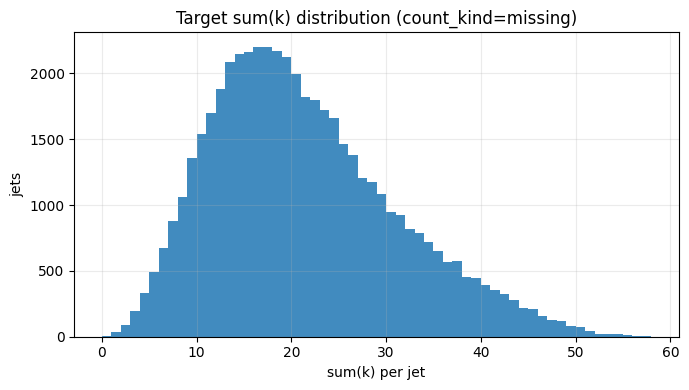

In [ ]:
# Build parentness + k targets
count_kind = str(CONFIG['target']['count_kind'])
max_k = CONFIG['target'].get('max_k', None)

# If max_k is None, auto-clip k_true to match decoder capacity.
# - For count_kind='missing': k_true is missing count, so max is (Kmax_children - 1)
# - For count_kind='children': k_true is children count, so max is Kmax_children
if max_k is None:
    if count_kind.lower() in ('missing', 'delta', 'deltan'):
        max_k = int(k_max) - 1
    else:
        max_k = int(k_max)
print('Target k clip max_k =', max_k)

parent_gt, k_true = tool.build_parent_targets_from_group_size(
    hlt_mask,
    group_size,
    count_kind=count_kind,
    max_k=max_k,
)

# Parent pos_weight on TRAIN tokens 是parent token在训练集中的比例
pos = float(parent_gt[train_idx][hlt_mask[train_idx]].sum())
neg = float(hlt_mask[train_idx].sum() - parent_gt[train_idx][hlt_mask[train_idx]].sum())
parent_pos_weight = (neg / max(pos, 1.0))
print(f"Parentness stats (train tokens): pos={int(pos):,} neg={int(neg):,} pos_weight={parent_pos_weight:.2f}")

# Quick plots
tgt_sum = k_true.sum(axis=1)
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'target_sumk.png')
plt.figure(figsize=(7, 4))
plt.hist(tgt_sum, bins= max(10, int(tgt_sum.max())), alpha=0.85)
plt.title(f"Target sum(k) distribution (count_kind={count_kind})")
plt.xlabel('sum(k) per jet')
plt.ylabel('jets')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()

In [ ]:
# Dataloaders
bs_pk = int(CONFIG['train_parent_k']['batch_size'])

train_ds = tool.JetParentKDataset(train_idx, feat_hlt_std=hlt_feat_std, mask_hlt=hlt_mask, parent_gt=parent_gt, k_true=k_true)
val_ds = tool.JetParentKDataset(val_idx, feat_hlt_std=hlt_feat_std, mask_hlt=hlt_mask, parent_gt=parent_gt, k_true=k_true)

train_loader = DataLoader(train_ds, batch_size=bs_pk, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=bs_pk)
print('Parent/K loaders:', len(train_loader), len(val_loader))

# Parent reco samples split (by sample index)
all_sidx = np.arange(len(samples), dtype=np.int64)
if len(all_sidx) > 0:
    s_train, s_temp = train_test_split(all_sidx, test_size=0.3, random_state=seed)
    s_val, s_test = train_test_split(s_temp, test_size=0.5, random_state=seed)
else:
    s_train = s_val = s_test = all_sidx
print(f"Reco sample split: train={len(s_train):,} val={len(s_val):,} test={len(s_test):,}")

bs_reco = int(CONFIG['train_reco']['batch_size'])
reco_train_ds = tool.ParentRecoDataset(
    s_train,
    samples=samples,
    children=children,
    feat_hlt_std=hlt_feat_std,
    mask_hlt=hlt_mask,
    off_child_feat_std=off_feat_std,
    k_max=k_max,
    k_true_token=k_true,
    parent_gt=parent_gt,
    k_true=k_true,
)
reco_val_ds = tool.ParentRecoDataset(
    s_val,
    samples=samples,
    children=children,
    feat_hlt_std=hlt_feat_std,
    mask_hlt=hlt_mask,
    off_child_feat_std=off_feat_std,
    k_max=k_max,
    k_true_token=k_true,
    parent_gt=parent_gt,
    k_true=k_true,
)

reco_train_loader = DataLoader(reco_train_ds, batch_size=bs_reco, shuffle=True, drop_last=True)
reco_val_loader = DataLoader(reco_val_ds, batch_size=bs_reco)
print('Reco loaders:', len(reco_train_loader), len(reco_val_loader))

Parent/K loaders: 136 30
Reco sample split: train=533,269 val=114,272 test=114,273
Reco loaders: 1041 224


In [6]:
# Build model

# Initialize k head bias near a reasonable prior (on GT parent tokens)
if (parent_gt[train_idx] > 0.5).any():
    init_k_bias = float(k_true[train_idx][parent_gt[train_idx] > 0.5].mean())
else:
    init_k_bias = 0.5

mcfg = CONFIG['model']
model = OrderedUnmerger(
    input_dim=int(mcfg['input_dim']),
    embed_dim=int(mcfg['embed_dim']),
    num_heads=int(mcfg['num_heads']),
    num_layers_enc=int(mcfg['num_layers_enc']),
    num_layers_dec=int(mcfg['num_layers_dec']),
    ff_dim=int(mcfg['ff_dim']),
    dropout=float(mcfg['dropout']),
    k_max=int(mcfg['k_max']),
    k_softplus_beta=float(mcfg.get('k_softplus_beta', 0.2)),
    init_k_bias=float(init_k_bias),
).to(device)

print('init_k_bias:', init_k_bias)
print('Model params:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')

init_k_bias: 1.3672465085983276
Model params: 1.655686 M


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [7]:
# Stage 1: train parentness + k heads

cfg_pk = tool.TrainCfgPK(**{k: v for k, v in CONFIG['train_parent_k'].items() if k != 'batch_size'})
ckpt_pk = CONFIG['io']['ckpt_parent_k']

# If load_ckpt is provided, we skip training and load that checkpoint.
# If load_ckpt is None, we train (even if ckpt_pk already exists).
load_ckpt = CONFIG['io'].get('load_ckpt', None)
if load_ckpt is not None:
    print('Loading parent/k from:', load_ckpt)
    tool.load_checkpoint(model, load_ckpt, map_location=device)
else:
    print('Training parent/k...')
    t0 = time.time()
    info_pk = tool.train_parent_k(
        model,
        train_loader,
        val_loader,
        device,
        cfg_pk,
        pos_weight=float(parent_pos_weight),
        ckpt_path=ckpt_pk,
    )
    print('Done. time=', time.time() - t0, 's best=', info_pk.get('best'))

Training parent/k...
[Parent+K] Ep 001: train=0.7164 val_parent=0.4357 val_k=0.2140 val_sum=2.9312 prec=0.784 rec=0.834 no_imp=0
[Parent+K] Ep 002: train=0.6563 val_parent=0.4253 val_k=0.2133 val_sum=3.3046 prec=0.794 rec=0.802 no_imp=0
[Parent+K] Ep 003: train=0.6455 val_parent=0.4249 val_k=0.2127 val_sum=3.1313 prec=0.789 rec=0.833 no_imp=0
[Parent+K] Ep 004: train=0.6403 val_parent=0.4227 val_k=0.2116 val_sum=3.0733 prec=0.791 rec=0.831 no_imp=0
[Parent+K] Ep 005: train=0.6375 val_parent=0.4278 val_k=0.2119 val_sum=2.7602 prec=0.785 rec=0.859 no_imp=1
[Parent+K] Ep 006: train=0.6355 val_parent=0.4187 val_k=0.2113 val_sum=3.1140 prec=0.794 rec=0.826 no_imp=0
[Parent+K] Ep 007: train=0.6332 val_parent=0.4186 val_k=0.2103 val_sum=2.8830 prec=0.794 rec=0.826 no_imp=0
[Parent+K] Ep 008: train=0.6320 val_parent=0.4226 val_k=0.2101 val_sum=2.6199 prec=0.786 rec=0.861 no_imp=1
[Parent+K] Ep 009: train=0.6309 val_parent=0.4204 val_k=0.2104 val_sum=2.8466 prec=0.789 rec=0.846 no_imp=2
[Parent

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_parentness_heatmaps.png


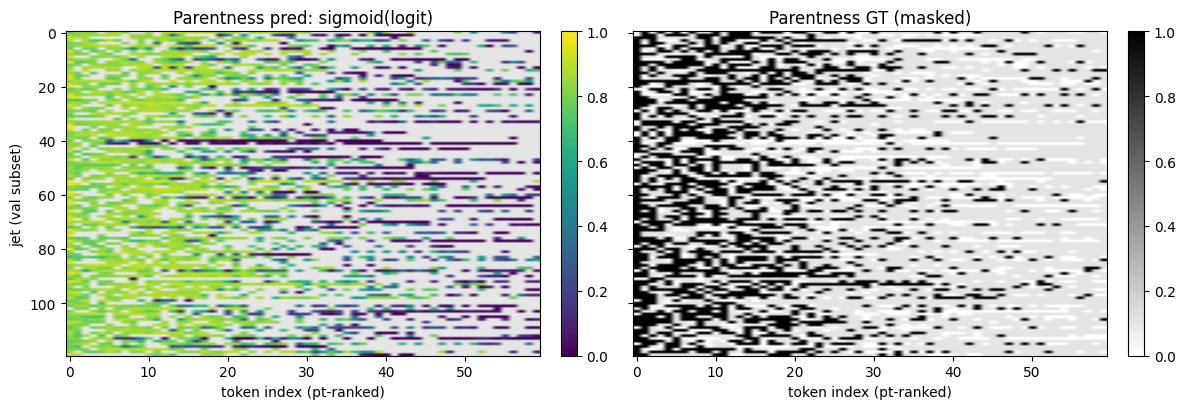

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_parentness_confusion_2x2.png


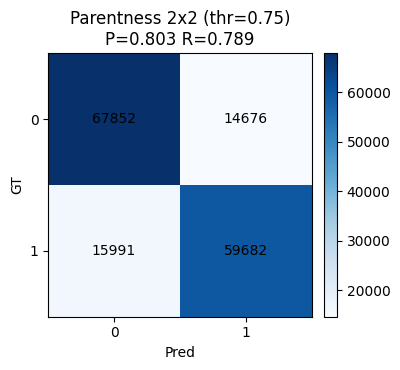

k_true (clipped) on GT parents: 1:62788 (82.97%), 2:4545 (6.01%), 3:5164 (6.82%), 4:1411 (1.86%), 5:972 (1.28%), 6:394 (0.52%), 7:399 (0.53%)
Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_k_heatmap_and_nonparent_hist.png


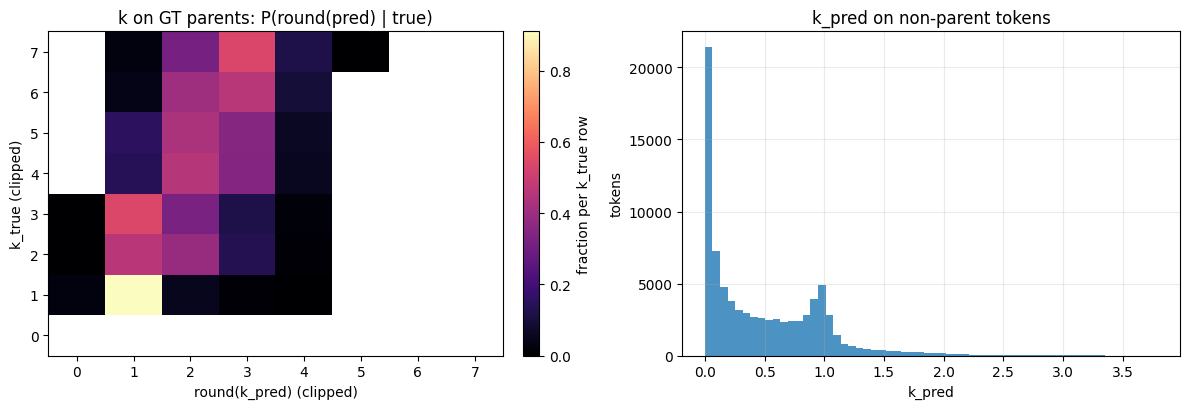

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_jetlevel_panels.png


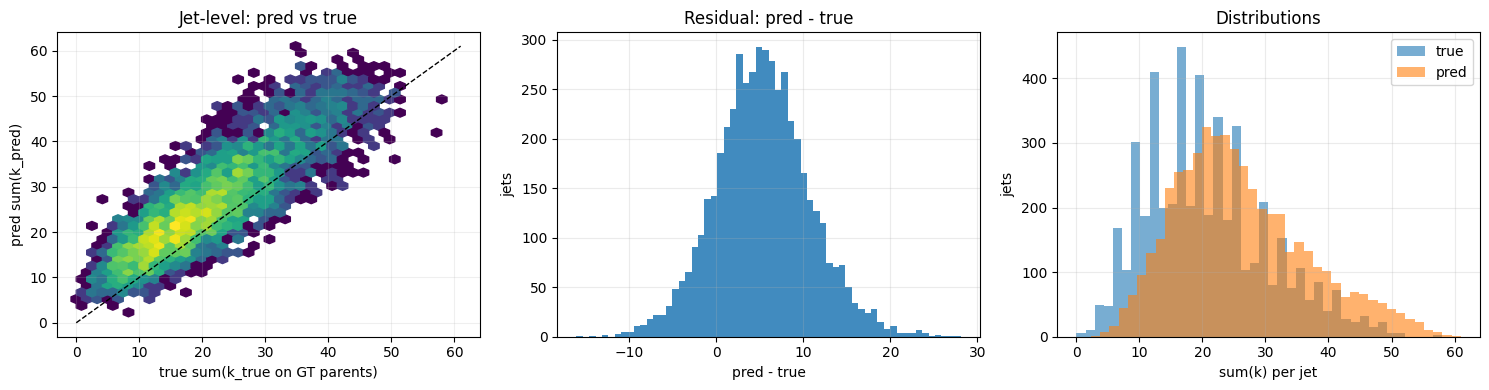

In [ ]:
# Stage 1 validation + visualization (before reco training)
# - Parentness: Jet×Token heatmap (pred vs GT)
# - k_pred: k_true vs round(k_pred) heatmap on GT parents + non-parent k_pred histogram
# - Jet-level: sum(k_pred) vs sum(k_true on GT parents) diagnostics

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

model.eval()

viz = CONFIG.get('viz_parent_k', {})
S_show = int(viz.get('tokens_show', 60))
J_show = int(viz.get('jets_show', 120))
J_eval = int(viz.get('jets_eval', 5000))
B_eval = int(viz.get('batch_size', 512))
# Heatmap bins: values are clipped to [0, max_k] where max_k matches the target k_true clip.
# For count_kind='missing' this should be Kmax_children-1, so bins are 0..7 (size 8).
# For count_kind='children' this should be Kmax_children, so bins are 0..8 (size 9).
K = int(max_k) + 1

# Choose jets from validation set for visualization/eval
val_jets = np.asarray(val_idx, dtype=np.int64)
if val_jets.size == 0:
    val_jets = np.asarray(train_idx, dtype=np.int64)
sel_show = val_jets[: min(J_show, val_jets.size)]
sel_eval = val_jets[: min(J_eval, val_jets.size)]

@torch.no_grad()
def _predict_parent_k(jet_indices: np.ndarray, batch_size: int = 512):
    probs = []
    kpreds = []
    for s0 in range(0, int(jet_indices.size), int(batch_size)):
        jj = jet_indices[s0 : s0 + int(batch_size)]
        x = torch.tensor(hlt_feat_std[jj], dtype=torch.float32, device=device)
        m = torch.tensor(hlt_mask[jj], dtype=torch.bool, device=device)
        out = model(x, m, parent_idx=None)
        probs.append(torch.sigmoid(out.parent_logit).detach().cpu().numpy())
        kpreds.append(out.k_pred.detach().cpu().numpy())
    return np.concatenate(probs, axis=0), np.concatenate(kpreds, axis=0)

# -----------------
# 1) Parentness heatmaps (pred vs GT)
# -----------------
prob_show, kpred_show = _predict_parent_k(sel_show, batch_size=min(B_eval, max(1, sel_show.size)))
mask_show = hlt_mask[sel_show]
gt_show = parent_gt[sel_show]

S_show = min(int(S_show), int(prob_show.shape[1]))
prob_hm = prob_show[:, :S_show].copy()
gt_hm = gt_show[:, :S_show].copy()
msk_hm = mask_show[:, :S_show]
prob_hm[~msk_hm] = np.nan
gt_hm[~msk_hm] = np.nan

fig1, ax = plt.subplots(1, 2, figsize=(12.0, 4.2), sharey=True)
cm1 = plt.cm.viridis.copy()
cm1.set_bad(color=(0.9, 0.9, 0.9, 1.0))
im0 = ax[0].imshow(prob_hm, aspect='auto', vmin=0.0, vmax=1.0, cmap=cm1)
ax[0].set_title('Parentness pred: sigmoid(logit)')
ax[0].set_xlabel('token index (pt-ranked)')
ax[0].set_ylabel('jet (val subset)')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

cm2 = plt.cm.gray_r.copy()
cm2.set_bad(color=(0.9, 0.9, 0.9, 1.0))
im1 = ax[1].imshow(gt_hm, aspect='auto', vmin=0.0, vmax=1.0, cmap=cm2)
ax[1].set_title('Parentness GT (masked)')
ax[1].set_xlabel('token index (pt-ranked)')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
fig1_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_parentness_heatmaps.png')
plt.savefig(fig1_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig1_path)
plt.show()

# -----------------
# 2) k diagnostics: (k_true vs round(k_pred)) heatmap on GT parents + non-parent k_pred histogram
# -----------------
prob_eval, kpred_eval = _predict_parent_k(sel_eval, batch_size=B_eval)
mask_eval = hlt_mask[sel_eval]
parent_eval = (parent_gt[sel_eval] > 0.5) & mask_eval
nonparent_eval = (parent_gt[sel_eval] <= 0.5) & mask_eval

# 2x2 confusion matrix for parentness (GT x Pred) on eval jets
thr_parent = float(CONFIG.get('infer', {}).get('thr_parent', 0.5))
pred_parent = (prob_eval > thr_parent) & mask_eval
gt_parent = (parent_gt[sel_eval] > 0.5) & mask_eval

tp = int((pred_parent & gt_parent).sum())
fp = int((pred_parent & (~gt_parent) & mask_eval).sum())
fn = int(((~pred_parent) & gt_parent).sum())
tn = int(((~pred_parent) & (~gt_parent) & mask_eval).sum())

prec = tp / max(1, (tp + fp))
rec = tp / max(1, (tp + fn))
cm2 = np.array([[tn, fp], [fn, tp]], dtype=np.int64)

figcm, axcm = plt.subplots(1, 1, figsize=(4.2, 3.8))
imcm = axcm.imshow(cm2, origin='upper', cmap='Blues')
axcm.set_title(f'Parentness 2x2 (thr={thr_parent:.2f})\nP={prec:.3f} R={rec:.3f}')
axcm.set_xlabel('Pred')
axcm.set_ylabel('GT')
axcm.set_xticks([0, 1])
axcm.set_yticks([0, 1])
axcm.set_xticklabels(['0', '1'])
axcm.set_yticklabels(['0', '1'])

for (r, c), v in np.ndenumerate(cm2):
    axcm.text(c, r, f'{int(v)}', ha='center', va='center', color='black')

plt.colorbar(imcm, ax=axcm, fraction=0.046, pad=0.04)
plt.tight_layout()
figcm_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_parentness_confusion_2x2.png')
plt.savefig(figcm_path, dpi=160, bbox_inches='tight')
print('Saved figure:', figcm_path)
plt.show()

k_true_eval = k_true[sel_eval]

# Confusion-like heatmap: x=pred (rounded), y=true (clipped)
kt = k_true_eval[parent_eval].astype(np.float32)
kp = kpred_eval[parent_eval].astype(np.float32)
kt_i = np.clip(np.rint(kt).astype(np.int64), 0, K - 1)
kp_i = np.clip(np.rint(kp).astype(np.int64), 0, K - 1)
mat = np.zeros((K, K), dtype=np.int64)
# Fast accumulation (counts of (k_true, round(k_pred)))
np.add.at(mat, (kt_i, kp_i), 1)

k_nonparent = kpred_eval[nonparent_eval].astype(np.float32)

# Quick check: k_true distribution on GT parents
k_counts = np.bincount(kt_i, minlength=K)
k_total = int(k_counts.sum())
if k_total > 0:
    msg = ', '.join([f"{i}:{int(k_counts[i])} ({k_counts[i]/k_total:.2%})" for i in range(K) if int(k_counts[i]) > 0])
    print('k_true (clipped) on GT parents:', msg)

fig2, ax = plt.subplots(1, 2, figsize=(12.0, 4.2))

# Normalize by row (each k_true bin) to reduce class-imbalance dominance.
# This visualizes P(round(k_pred)=j | k_true=i).
row_sum = mat.sum(axis=1, keepdims=True).astype(np.float32)
mat_frac = mat.astype(np.float32) / np.clip(row_sum, 1.0, None)
# Hide empty rows and exact zeros for readability
mat_frac[row_sum.squeeze(1) <= 0] = np.nan
mat_frac[mat_frac <= 0] = np.nan

im = ax[0].imshow(
    mat_frac,
    origin='lower',
    aspect='auto',
    cmap='magma',
    vmin=0.0,
    vmax=float(np.nanmax(mat_frac)) if np.isfinite(mat_frac).any() else 1.0,
)
ax[0].set_title('k on GT parents: P(round(pred) | true)')
ax[0].set_xlabel('round(k_pred) (clipped)')
ax[0].set_ylabel('k_true (clipped)')
ax[0].set_xticks(range(K))
ax[0].set_yticks(range(K))
cbar = plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label('fraction per k_true row')

ax[1].hist(k_nonparent, bins=60, alpha=0.8)
ax[1].set_title('k_pred on non-parent tokens')
ax[1].set_xlabel('k_pred')
ax[1].set_ylabel('tokens')
ax[1].grid(True, alpha=0.25)

plt.tight_layout()
fig2_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_k_heatmap_and_nonparent_hist.png')
plt.savefig(fig2_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig2_path)
plt.show()

# -----------------
# 3) Jet-level diagnostics: sum(k_pred) vs sum(k_true on GT parents)
# -----------------
# Note: this focuses on merged-parent contribution only (robust for both count_kind options).
jet_true = (k_true_eval * parent_gt[sel_eval]).sum(axis=1).astype(np.float32)
jet_pred = (kpred_eval * mask_eval.astype(np.float32)).sum(axis=1).astype(np.float32)

res = jet_pred - jet_true

fig3, ax = plt.subplots(1, 3, figsize=(15.0, 4.0))
ax[0].hexbin(jet_true, jet_pred, gridsize=35, bins='log', mincnt=1)
mx = float(max(jet_true.max(), jet_pred.max(), 1.0))
ax[0].plot([0, mx], [0, mx], 'k--', linewidth=1)
ax[0].set_title('Jet-level: pred vs true')
ax[0].set_xlabel('true sum(k_true on GT parents)')
ax[0].set_ylabel('pred sum(k_pred)')
ax[0].grid(True, alpha=0.2)

ax[1].hist(res, bins=60, alpha=0.85)
ax[1].set_title('Residual: pred - true')
ax[1].set_xlabel('pred - true')
ax[1].set_ylabel('jets')
ax[1].grid(True, alpha=0.25)

ax[2].hist(jet_true, bins=40, alpha=0.6, label='true')
ax[2].hist(jet_pred, bins=40, alpha=0.6, label='pred')
ax[2].set_title('Distributions')
ax[2].set_xlabel('sum(k) per jet')
ax[2].set_ylabel('jets')
ax[2].legend()
ax[2].grid(True, alpha=0.25)

plt.tight_layout()
fig3_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_jetlevel_panels.png')
plt.savefig(fig3_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig3_path)
plt.show()


In [ ]:
# Stage 2: teacher-forced reconstruction (Ordered)

cfg_reco = tool.TrainCfgReco(**{k: v for k, v in CONFIG['train_reco'].items() if k != 'batch_size'})
ckpt_reco = CONFIG['io']['ckpt_reco']

# If load_ckpt is provided, we skip reco training and load that checkpoint.
# If load_ckpt is None, we train reco (even if ckpt_reco already exists).
load_ckpt = CONFIG['io'].get('load_ckpt', None)
if load_ckpt is not None:
    print('Loading reco from:', load_ckpt)
    tool.load_checkpoint(model, load_ckpt, map_location=device)
elif len(samples) == 0:
    print('No merged-parent samples; skip reco training.')
else:
    print('Training reco (teacher forcing)...')
    t0 = time.time()
    info_reco = tool.train_reco_teacher_forced(
        model,
        reco_train_loader,
        reco_val_loader,
        device,
        cfg_reco,
        pos_weight=float(parent_pos_weight),
        ckpt_path=ckpt_reco,
    )
    print('Done. time=', time.time() - t0, 's best=', info_reco.get('best'))

Training reco (teacher forcing)...
[Reco/TF] Ep 001: train=0.3999 val=0.1742 no_imp=0
[Reco/TF] Ep 002: train=0.1919 val=0.1781 no_imp=1
[Reco/TF] Ep 003: train=0.1821 val=0.1746 no_imp=2
[Reco/TF] Ep 004: train=0.1773 val=0.1688 no_imp=0
[Reco/TF] Ep 005: train=0.1740 val=0.1708 no_imp=1
[Reco/TF] Ep 006: train=0.1718 val=0.1636 no_imp=0
[Reco/TF] Ep 007: train=0.1702 val=0.1711 no_imp=1
[Reco/TF] Ep 008: train=0.1693 val=0.1662 no_imp=2
[Reco/TF] Ep 009: train=0.1683 val=0.1639 no_imp=3
[Reco/TF] Ep 010: train=0.1674 val=0.1736 no_imp=4
[Reco/TF] Ep 011: train=0.1667 val=0.1817 no_imp=5
[Reco/TF] Ep 012: train=0.1661 val=0.1681 no_imp=6
[Reco/TF] Early stopping.
Done. time= 3363.6076831817627 s best= 0.16357751423493028


Loading pre-reco parent/k checkpoint: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\ckpts\parent_k.pt
Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_parentness_heatmaps_pre_post.png


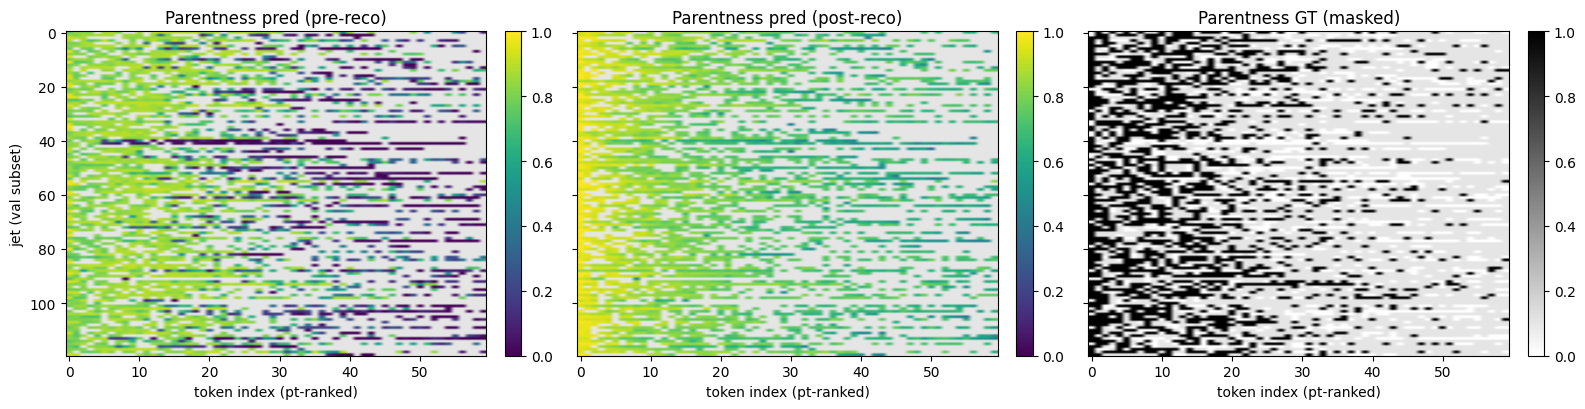

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_parentness_confusion_2x2_pre_post.png


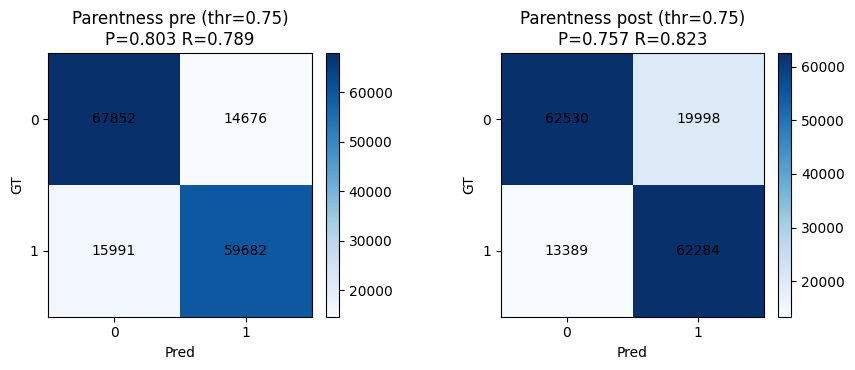

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_k_heatmap_and_nonparent_hist_pre_post.png


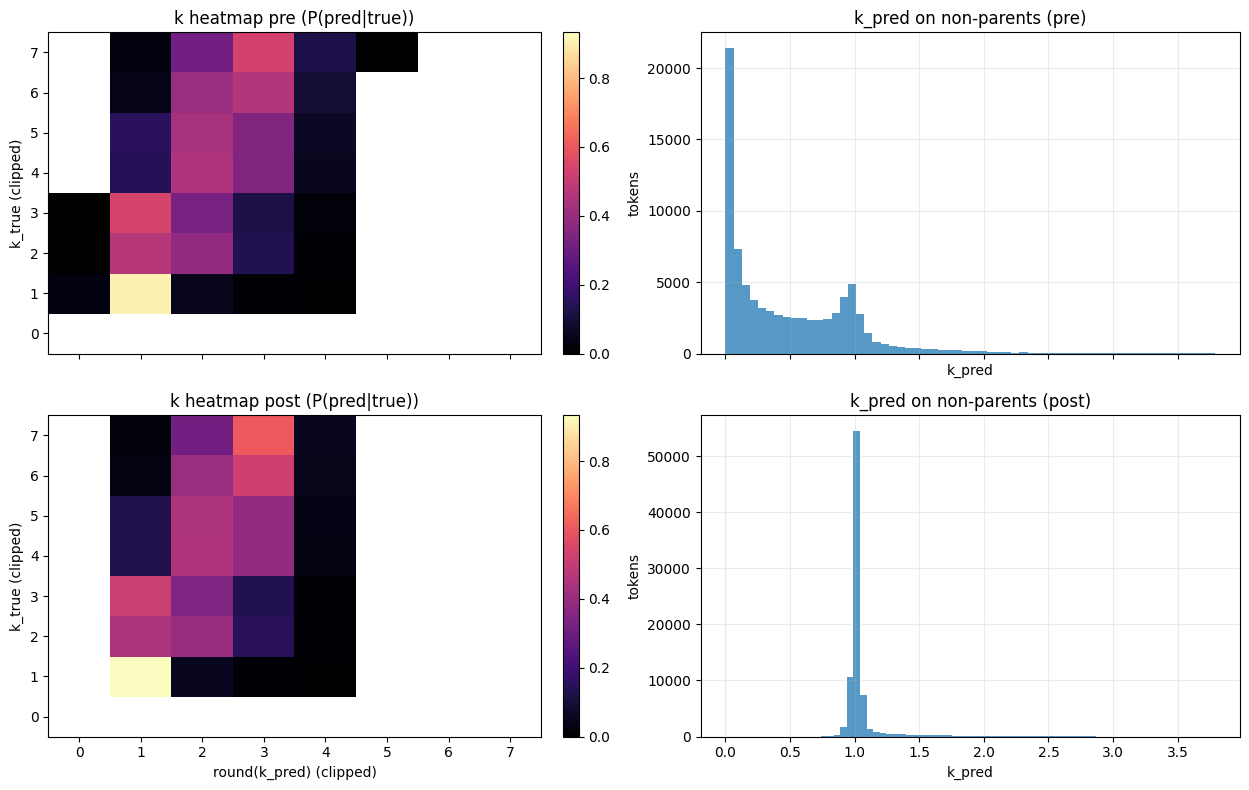

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\pk_jetlevel_pre_post.png


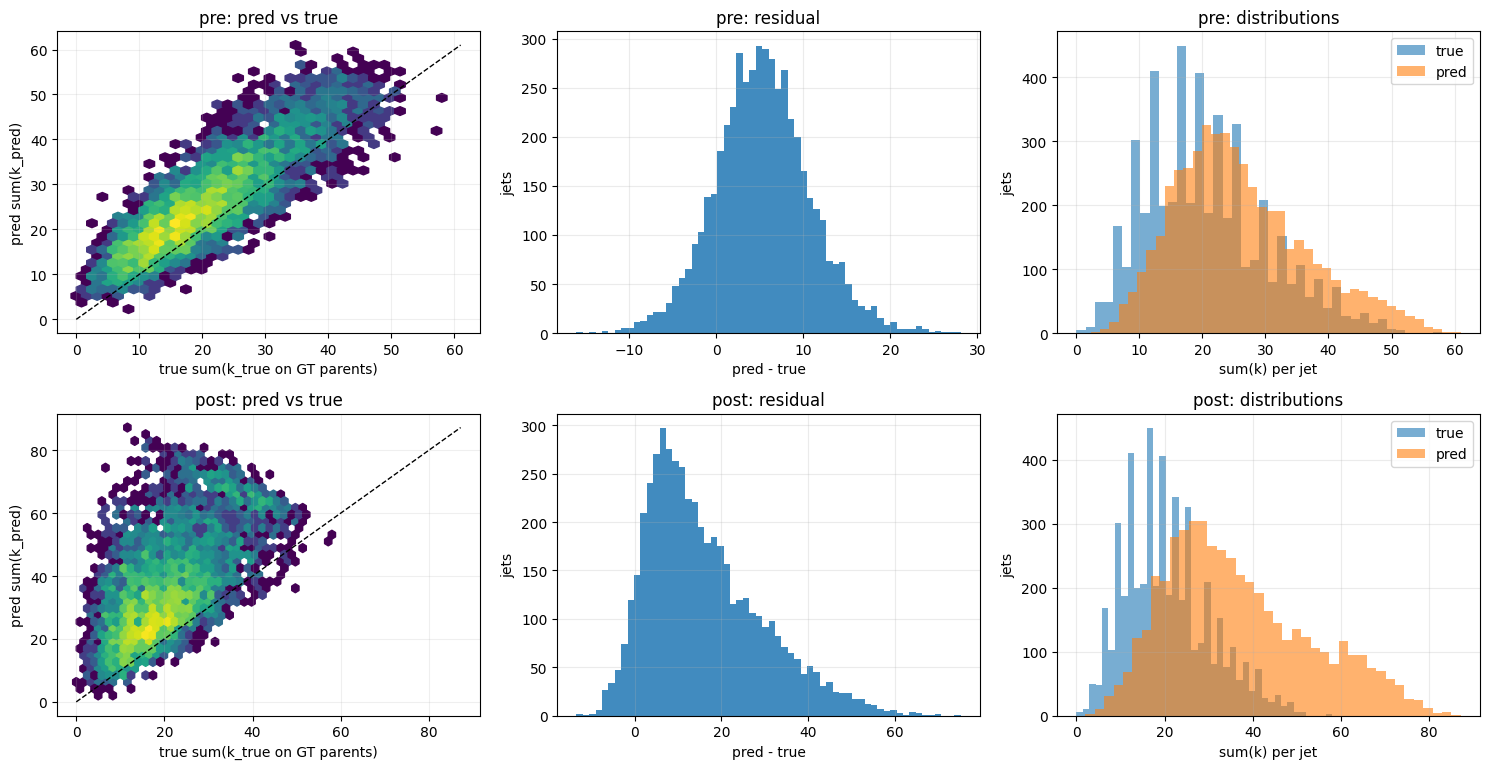

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\reco_log_pt_panels.png


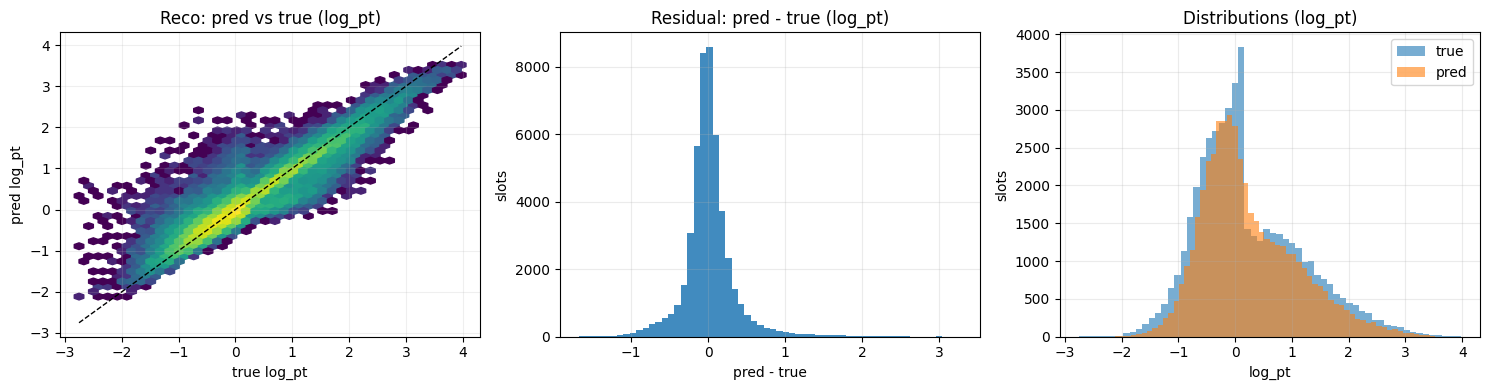

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\reco_dEta_panels.png


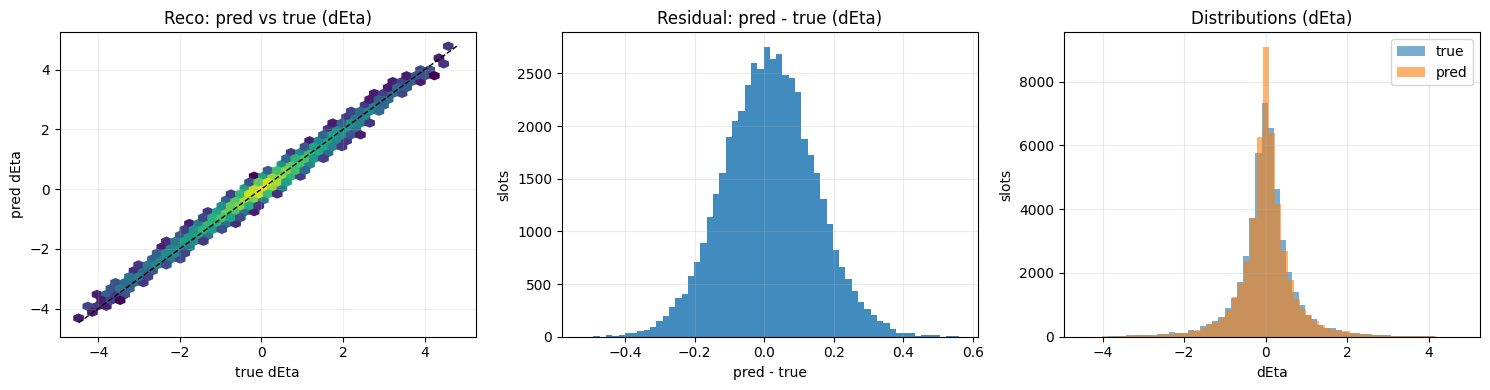

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\reco_dPhi_panels.png


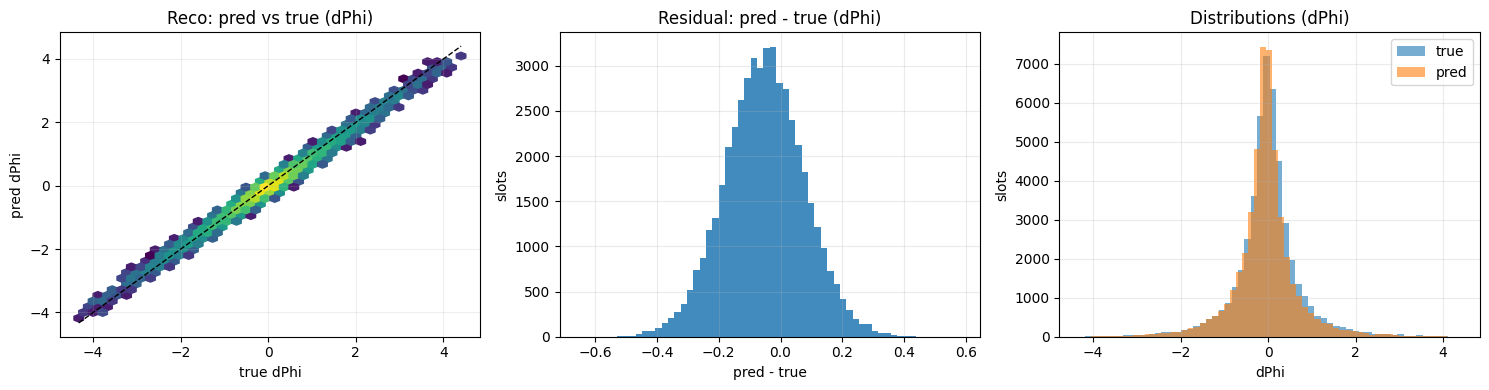

Saved figure: d:\PracticeTagging\unmerge\unmerger\runs\OrderedUnmerger_kpred\figs\reco_log_E_panels.png


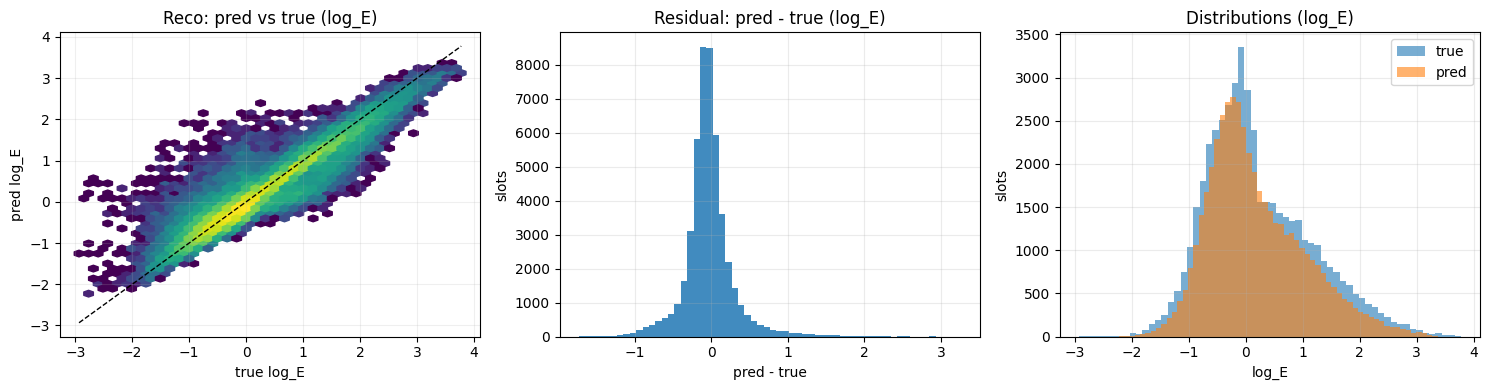

In [ ]:
# Post-reco validation: compare Parentness+K (pre vs post reco) + 4D reconstruction panels

import os
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------
# Part 1) Parentness + k: compare pre-reco (parent/k checkpoint) vs post-reco (current model)
# -----------------

viz_pk2 = CONFIG.get('viz_parent_k', {})
S_show = int(viz_pk2.get('tokens_show', 60))
J_show = int(viz_pk2.get('jets_show', 120))
J_eval = int(viz_pk2.get('jets_eval', 5000))
B_eval = int(viz_pk2.get('batch_size', 512))
# Keep k heatmap bins consistent with target k_true clipping.
K = int(max_k) + 1

val_jets = np.asarray(val_idx, dtype=np.int64)
if val_jets.size == 0:
    val_jets = np.asarray(train_idx, dtype=np.int64)
sel_show = val_jets[: min(J_show, val_jets.size)]
sel_eval = val_jets[: min(J_eval, val_jets.size)]

@torch.no_grad()
def _predict_parent_k_with_model(model_, jet_indices: np.ndarray, batch_size: int = 512):
    model_.eval()
    probs = []
    kpreds = []
    for s0 in range(0, int(jet_indices.size), int(batch_size)):
        jj = jet_indices[s0 : s0 + int(batch_size)]
        x = torch.tensor(hlt_feat_std[jj], dtype=torch.float32, device=device)
        m = torch.tensor(hlt_mask[jj], dtype=torch.bool, device=device)
        out = model_(x, m, parent_idx=None)
        probs.append(torch.sigmoid(out.parent_logit).detach().cpu().numpy())
        kpreds.append(out.k_pred.detach().cpu().numpy())
    return np.concatenate(probs, axis=0), np.concatenate(kpreds, axis=0)

# Build pre-reco model snapshot
ckpt_pk = CONFIG['io'].get('ckpt_parent_k', None)
model_pre = copy.deepcopy(model).to(device)
if ckpt_pk is not None and os.path.exists(str(ckpt_pk)):
    print('Loading pre-reco parent/k checkpoint:', ckpt_pk)
    tool.load_checkpoint(model_pre, ckpt_pk, map_location=device)
else:
    print('WARNING: ckpt_parent_k not found; pre/post compare will use current model for both.')

model_post = model

# ---------
# (0) Parentness Jet×Token heatmaps (pre vs post vs GT)
# ---------
prob_pre_show, _ = _predict_parent_k_with_model(model_pre, sel_show, batch_size=min(B_eval, max(1, sel_show.size)))
prob_post_show, _ = _predict_parent_k_with_model(model_post, sel_show, batch_size=min(B_eval, max(1, sel_show.size)))
mask_show = hlt_mask[sel_show]
gt_show = parent_gt[sel_show]

S_show_eff = min(int(S_show), int(prob_pre_show.shape[1]))
msk_hm = mask_show[:, :S_show_eff]

pre_hm = prob_pre_show[:, :S_show_eff].copy()
post_hm = prob_post_show[:, :S_show_eff].copy()
gt_hm = gt_show[:, :S_show_eff].copy()
pre_hm[~msk_hm] = np.nan
post_hm[~msk_hm] = np.nan
gt_hm[~msk_hm] = np.nan

figH, axH = plt.subplots(1, 3, figsize=(16.0, 4.2), sharey=True)
cm_pred = plt.cm.viridis.copy(); cm_pred.set_bad(color=(0.9, 0.9, 0.9, 1.0))
cm_gt = plt.cm.gray_r.copy(); cm_gt.set_bad(color=(0.9, 0.9, 0.9, 1.0))

im0 = axH[0].imshow(pre_hm, aspect='auto', vmin=0.0, vmax=1.0, cmap=cm_pred)
axH[0].set_title('Parentness pred (pre-reco)')
axH[0].set_xlabel('token index (pt-ranked)')
axH[0].set_ylabel('jet (val subset)')
plt.colorbar(im0, ax=axH[0], fraction=0.046, pad=0.04)

im1 = axH[1].imshow(post_hm, aspect='auto', vmin=0.0, vmax=1.0, cmap=cm_pred)
axH[1].set_title('Parentness pred (post-reco)')
axH[1].set_xlabel('token index (pt-ranked)')
plt.colorbar(im1, ax=axH[1], fraction=0.046, pad=0.04)

im2 = axH[2].imshow(gt_hm, aspect='auto', vmin=0.0, vmax=1.0, cmap=cm_gt)
axH[2].set_title('Parentness GT (masked)')
axH[2].set_xlabel('token index (pt-ranked)')
plt.colorbar(im2, ax=axH[2], fraction=0.046, pad=0.04)

plt.tight_layout()
figH_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_parentness_heatmaps_pre_post.png')
plt.savefig(figH_path, dpi=160, bbox_inches='tight')
print('Saved figure:', figH_path)
plt.show()

# ---------
# (1) Parentness 2x2 confusion (pre vs post)
# ---------
thr_parent = float(CONFIG.get('infer', {}).get('thr_parent', 0.5))
prob_pre_eval, kpred_pre_eval = _predict_parent_k_with_model(model_pre, sel_eval, batch_size=B_eval)
prob_post_eval, kpred_post_eval = _predict_parent_k_with_model(model_post, sel_eval, batch_size=B_eval)
mask_eval = hlt_mask[sel_eval]
gt_parent = (parent_gt[sel_eval] > 0.5) & mask_eval
pred_pre = (prob_pre_eval > thr_parent) & mask_eval
pred_post = (prob_post_eval > thr_parent) & mask_eval

def _confusion(pred: np.ndarray, gt: np.ndarray, mask: np.ndarray):
    tp = int((pred & gt).sum())
    fp = int((pred & (~gt) & mask).sum())
    fn = int(((~pred) & gt).sum())
    tn = int(((~pred) & (~gt) & mask).sum())
    prec = tp / max(1, (tp + fp))
    rec = tp / max(1, (tp + fn))
    cm = np.array([[tn, fp], [fn, tp]], dtype=np.int64)
    return cm, prec, rec

cm_pre, p_pre, r_pre = _confusion(pred_pre, gt_parent, mask_eval)
cm_post, p_post, r_post = _confusion(pred_post, gt_parent, mask_eval)

figcm, ax = plt.subplots(1, 2, figsize=(9.2, 3.8))
for aa, cmx, title in [
    (ax[0], cm_pre, f'Parentness pre (thr={thr_parent:.2f})\nP={p_pre:.3f} R={r_pre:.3f}'),
    (ax[1], cm_post, f'Parentness post (thr={thr_parent:.2f})\nP={p_post:.3f} R={r_post:.3f}'),
]:
    im = aa.imshow(cmx, origin='upper', cmap='Blues')
    aa.set_xlabel('Pred')
    aa.set_ylabel('GT')
    aa.set_xticks([0, 1]); aa.set_yticks([0, 1])
    aa.set_xticklabels(['0', '1']); aa.set_yticklabels(['0', '1'])
    aa.set_title(title)
    for (rr, cc), v in np.ndenumerate(cmx):
        aa.text(cc, rr, f'{int(v)}', ha='center', va='center', color='black')
    plt.colorbar(im, ax=aa, fraction=0.046, pad=0.04)

plt.tight_layout()
figcm_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_parentness_confusion_2x2_pre_post.png')
plt.savefig(figcm_path, dpi=160, bbox_inches='tight')
print('Saved figure:', figcm_path)
plt.show()

# ---------
# (2) k heatmap + non-parent hist (pre vs post)
# ---------
parent_eval = gt_parent
nonparent_eval = (~gt_parent) & mask_eval
k_true_eval = k_true[sel_eval]

kt = k_true_eval[parent_eval].astype(np.float32)
kt_i = np.clip(np.rint(kt).astype(np.int64), 0, K - 1)

kp_pre = kpred_pre_eval[parent_eval].astype(np.float32)
kp_post = kpred_post_eval[parent_eval].astype(np.float32)
kp_pre_i = np.clip(np.rint(kp_pre).astype(np.int64), 0, K - 1)
kp_post_i = np.clip(np.rint(kp_post).astype(np.int64), 0, K - 1)

mat_pre = np.zeros((K, K), dtype=np.int64)
mat_post = np.zeros((K, K), dtype=np.int64)
np.add.at(mat_pre, (kt_i, kp_pre_i), 1)
np.add.at(mat_post, (kt_i, kp_post_i), 1)

row_sum_pre = mat_pre.sum(axis=1, keepdims=True).astype(np.float32)
row_sum_post = mat_post.sum(axis=1, keepdims=True).astype(np.float32)
mat_pre_f = mat_pre.astype(np.float32) / np.clip(row_sum_pre, 1.0, None)
mat_post_f = mat_post.astype(np.float32) / np.clip(row_sum_post, 1.0, None)
mat_pre_f[row_sum_pre.squeeze(1) <= 0] = np.nan
mat_post_f[row_sum_post.squeeze(1) <= 0] = np.nan
mat_pre_f[mat_pre_f <= 0] = np.nan
mat_post_f[mat_post_f <= 0] = np.nan

k_non_pre = kpred_pre_eval[nonparent_eval].astype(np.float32)
k_non_post = kpred_post_eval[nonparent_eval].astype(np.float32)

vmax = float(np.nanmax(np.concatenate([mat_pre_f[np.isfinite(mat_pre_f)], mat_post_f[np.isfinite(mat_post_f)]], axis=0))) if (np.isfinite(mat_pre_f).any() or np.isfinite(mat_post_f).any()) else 1.0

figk, ax = plt.subplots(2, 2, figsize=(12.6, 8.0), sharex='col')

im0 = ax[0, 0].imshow(mat_pre_f, origin='lower', aspect='auto', cmap='magma', vmin=0.0, vmax=vmax)
ax[0, 0].set_title('k heatmap pre (P(pred|true))')
ax[0, 0].set_ylabel('k_true (clipped)')
ax[0, 0].set_xticks(range(K)); ax[0, 0].set_yticks(range(K))
plt.colorbar(im0, ax=ax[0, 0], fraction=0.046, pad=0.04)

im1 = ax[1, 0].imshow(mat_post_f, origin='lower', aspect='auto', cmap='magma', vmin=0.0, vmax=vmax)
ax[1, 0].set_title('k heatmap post (P(pred|true))')
ax[1, 0].set_xlabel('round(k_pred) (clipped)')
ax[1, 0].set_ylabel('k_true (clipped)')
ax[1, 0].set_xticks(range(K)); ax[1, 0].set_yticks(range(K))
plt.colorbar(im1, ax=ax[1, 0], fraction=0.046, pad=0.04)

ax[0, 1].hist(k_non_pre, bins=60, alpha=0.75)
ax[0, 1].set_title('k_pred on non-parents (pre)')
ax[0, 1].set_xlabel('k_pred'); ax[0, 1].set_ylabel('tokens')
ax[0, 1].grid(True, alpha=0.25)

ax[1, 1].hist(k_non_post, bins=60, alpha=0.75)
ax[1, 1].set_title('k_pred on non-parents (post)')
ax[1, 1].set_xlabel('k_pred'); ax[1, 1].set_ylabel('tokens')
ax[1, 1].grid(True, alpha=0.25)

plt.tight_layout()
figk_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_k_heatmap_and_nonparent_hist_pre_post.png')
plt.savefig(figk_path, dpi=160, bbox_inches='tight')
print('Saved figure:', figk_path)
plt.show()

# ---------
# (3) Jet-level sum(k) panels (pre vs post)
# ---------
jet_true = (k_true_eval * parent_gt[sel_eval]).sum(axis=1).astype(np.float32)
jet_pred_pre = (kpred_pre_eval * mask_eval.astype(np.float32)).sum(axis=1).astype(np.float32)
jet_pred_post = (kpred_post_eval * mask_eval.astype(np.float32)).sum(axis=1).astype(np.float32)

figj, ax = plt.subplots(2, 3, figsize=(15.0, 7.8))

def _row(axr, pred, tag):
    axr[0].hexbin(jet_true, pred, gridsize=35, bins='log', mincnt=1)
    mx = float(max(jet_true.max(), pred.max(), 1.0))
    axr[0].plot([0, mx], [0, mx], 'k--', linewidth=1)
    axr[0].set_title(f'{tag}: pred vs true')
    axr[0].set_xlabel('true sum(k_true on GT parents)')
    axr[0].set_ylabel('pred sum(k_pred)')
    axr[0].grid(True, alpha=0.2)

    res = pred - jet_true
    axr[1].hist(res, bins=60, alpha=0.85)
    axr[1].set_title(f'{tag}: residual')
    axr[1].set_xlabel('pred - true')
    axr[1].set_ylabel('jets')
    axr[1].grid(True, alpha=0.25)

    axr[2].hist(jet_true, bins=40, alpha=0.6, label='true')
    axr[2].hist(pred, bins=40, alpha=0.6, label='pred')
    axr[2].set_title(f'{tag}: distributions')
    axr[2].set_xlabel('sum(k) per jet')
    axr[2].set_ylabel('jets')
    axr[2].legend(); axr[2].grid(True, alpha=0.25)

_row(ax[0], jet_pred_pre, 'pre')
_row(ax[1], jet_pred_post, 'post')

plt.tight_layout()
figj_path = os.path.join(CONFIG['io']['fig_dir'], 'pk_jetlevel_pre_post.png')
plt.savefig(figj_path, dpi=160, bbox_inches='tight')
print('Saved figure:', figj_path)
plt.show()

# -----------------
# Part 2) Reconstruction: 4D panels
# -----------------

viz_reco = CONFIG.get('viz_reco', {})
nb_max = int(viz_reco.get('n_val_batches', 40))
bins = int(viz_reco.get('bins', 60))

model_post.eval()
true_all = []
pred_all = []

with torch.no_grad():
    for ib, batch in enumerate(reco_val_loader):
        if ib >= nb_max:
            break
        x = batch['hlt'].to(device)
        m = batch['mask_hlt'].to(device)
        parent_idx = batch['parent_idx'].to(device)
        tgt = batch['tgt'].to(device)
        tgt_mask = batch['tgt_mask'].to(device)
        out = model_post(x, m, parent_idx=parent_idx)
        pred = out.child_feat
        assert pred is not None

        sel = tgt_mask.reshape(-1)
        pred_v = pred.reshape(-1, pred.shape[-1])[sel].detach().cpu().numpy()
        tgt_v = tgt.reshape(-1, tgt.shape[-1])[sel].detach().cpu().numpy()
        if pred_v.shape[0] > 0:
            pred_all.append(pred_v)
            true_all.append(tgt_v)

pred_np = np.concatenate(pred_all, axis=0) if pred_all else np.zeros((0, 4), dtype=np.float32)
true_np = np.concatenate(true_all, axis=0) if true_all else np.zeros((0, 4), dtype=np.float32)

dim_names = ['log_pt', 'dEta', 'dPhi', 'log_E']
for d, name in enumerate(dim_names):
    figB, ax = plt.subplots(1, 3, figsize=(15.0, 4.0))
    if true_np.shape[0] > 0:
        t = true_np[:, d]
        p = pred_np[:, d]
        ax[0].hexbin(t, p, gridsize=40, bins='log', mincnt=1)
        mx = float(max(np.max(t), np.max(p), 1.0))
        mn = float(min(np.min(t), np.min(p), -1.0))
        ax[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
        ax[0].set_title(f'Reco: pred vs true ({name})')
        ax[0].set_xlabel(f'true {name}')
        ax[0].set_ylabel(f'pred {name}')
        ax[0].grid(True, alpha=0.2)

        r = p - t
        ax[1].hist(r, bins=bins, alpha=0.85)
        ax[1].set_title(f'Residual: pred - true ({name})')
        ax[1].set_xlabel('pred - true')
        ax[1].set_ylabel('slots')
        ax[1].grid(True, alpha=0.25)

        ax[2].hist(t, bins=bins, alpha=0.6, label='true')
        ax[2].hist(p, bins=bins, alpha=0.6, label='pred')
        ax[2].set_title(f'Distributions ({name})')
        ax[2].set_xlabel(name)
        ax[2].set_ylabel('slots')
        ax[2].legend(); ax[2].grid(True, alpha=0.25)
    else:
        for a in ax:
            a.axis('off')

    plt.tight_layout()
    fig_path = os.path.join(CONFIG['io']['fig_dir'], f'reco_{name}_panels.png')
    plt.savefig(fig_path, dpi=160, bbox_inches='tight')
    print('Saved figure:', fig_path)
    plt.show()

In [11]:
# Build full unmerged view for downstream dual-view tagger (uses trained unmerger)

infer = CONFIG['infer']
print('Building unmerged view for ALL jets...')

t0 = time.time()
unm_raw_all, unm_mask_all, unm_feat_std_all = tool.build_unmerged_view_ordered(
    model,
    device,
    hlt_raw=hlt_raw,
    hlt_mask=hlt_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_axis=hlt_axis,
    feat_means=feat_means,
    feat_stds=feat_stds,
    max_particles=int(CONFIG['pack_max_particles']),
    thr_parent=float(infer['thr_parent']),
    max_split_parents=int(infer['max_split_parents']),
    max_k_per_parent=int(infer['max_k_per_parent']),
    count_kind=count_kind,
)
print('Done. time=', time.time() - t0, 's')

print('UNM feat:', unm_feat_std_all.shape, 'mask:', unm_mask_all.shape)
print('Packed tokens mean=', float(unm_mask_all.sum(axis=1).mean()))

Building unmerged view for ALL jets...
Done. time= 295.92477917671204 s
UNM feat: (50000, 100, 4) mask: (50000, 100)
Packed tokens mean= 50.51046


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Teacher] Ep 001: val_auc=0.79859 best=0.79859 no_imp=0
[Teacher] Ep 002: val_auc=0.87498 best=0.87498 no_imp=0
[Teacher] Ep 003: val_auc=0.90435 best=0.90435 no_imp=0
[Teacher] Ep 004: val_auc=0.91702 best=0.91702 no_imp=0
[Teacher] Ep 005: val_auc=0.92195 best=0.92195 no_imp=0
[Teacher] Ep 006: val_auc=0.92489 best=0.92489 no_imp=0
[Teacher] Ep 007: val_auc=0.92223 best=0.92489 no_imp=1
[Teacher] Ep 008: val_auc=0.92574 best=0.92574 no_imp=0
[Teacher] Ep 009: val_auc=0.92897 best=0.92897 no_imp=0
[Teacher] Ep 010: val_auc=0.92939 best=0.92939 no_imp=0
[Teacher] Ep 011: val_auc=0.93051 best=0.93051 no_imp=0
[Teacher] Ep 012: val_auc=0.92411 best=0.93051 no_imp=1
[Teacher] Ep 013: val_auc=0.93088 best=0.93088 no_imp=0
[Teacher] Ep 014: val_auc=0.92605 best=0.93088 no_imp=1
[Teacher] Ep 015: val_auc=0.93053 best=0.93088 no_imp=2
[Teacher] Ep 016: val_auc=0.92386 best=0.93088 no_imp=3
[Teacher] Ep 017: val_auc=0.93127 best=0.93127 no_imp=0
[Teacher] Ep 018: val_auc=0.92998 best=0.93127 n

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[HLT] Ep 001: val_auc=0.79779 best=0.79779 no_imp=0
[HLT] Ep 002: val_auc=0.86232 best=0.86232 no_imp=0
[HLT] Ep 003: val_auc=0.87913 best=0.87913 no_imp=0
[HLT] Ep 004: val_auc=0.88919 best=0.88919 no_imp=0
[HLT] Ep 005: val_auc=0.89357 best=0.89357 no_imp=0
[HLT] Ep 006: val_auc=0.89026 best=0.89357 no_imp=1
[HLT] Ep 007: val_auc=0.90081 best=0.90081 no_imp=0
[HLT] Ep 008: val_auc=0.89802 best=0.90081 no_imp=1
[HLT] Ep 009: val_auc=0.90375 best=0.90375 no_imp=0
[HLT] Ep 010: val_auc=0.90351 best=0.90375 no_imp=1
[HLT] Ep 011: val_auc=0.90469 best=0.90469 no_imp=0
[HLT] Ep 012: val_auc=0.90665 best=0.90665 no_imp=0
[HLT] Ep 013: val_auc=0.90083 best=0.90665 no_imp=1
[HLT] Ep 014: val_auc=0.90329 best=0.90665 no_imp=2
[HLT] Ep 015: val_auc=0.90617 best=0.90665 no_imp=3
[HLT] Ep 016: val_auc=0.90291 best=0.90665 no_imp=4
[HLT] Ep 017: val_auc=0.90735 best=0.90735 no_imp=0
[HLT] Ep 018: val_auc=0.90232 best=0.90735 no_imp=1
[HLT] Ep 019: val_auc=0.90768 best=0.90768 no_imp=0
[HLT] Ep 020

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[HLT+KD] Ep 001: val_auc=0.84214 best=0.84214 no_imp=0
[HLT+KD] Ep 002: val_auc=0.87521 best=0.87521 no_imp=0
[HLT+KD] Ep 003: val_auc=0.89482 best=0.89482 no_imp=0
[HLT+KD] Ep 004: val_auc=0.89660 best=0.89660 no_imp=0
[HLT+KD] Ep 005: val_auc=0.89913 best=0.89913 no_imp=0
[HLT+KD] Ep 006: val_auc=0.90068 best=0.90068 no_imp=0
[HLT+KD] Ep 007: val_auc=0.90422 best=0.90422 no_imp=0
[HLT+KD] Ep 008: val_auc=0.90366 best=0.90422 no_imp=1
[HLT+KD] Ep 009: val_auc=0.90419 best=0.90422 no_imp=2
[HLT+KD] Ep 010: val_auc=0.90788 best=0.90788 no_imp=0
[HLT+KD] Ep 011: val_auc=0.90449 best=0.90788 no_imp=1
[HLT+KD] Ep 012: val_auc=0.90822 best=0.90822 no_imp=0
[HLT+KD] Ep 013: val_auc=0.90721 best=0.90822 no_imp=1
[HLT+KD] Ep 014: val_auc=0.90805 best=0.90822 no_imp=2
[HLT+KD] Ep 015: val_auc=0.91002 best=0.91002 no_imp=0
[HLT+KD] Ep 016: val_auc=0.91017 best=0.91017 no_imp=0
[HLT+KD] Ep 017: val_auc=0.91120 best=0.91120 no_imp=0
[HLT+KD] Ep 018: val_auc=0.91024 best=0.91120 no_imp=1
[HLT+KD] E

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Dual+KD] Ep 001: val_auc=0.81914 best=0.81914 no_imp=0
[Dual+KD] Ep 002: val_auc=0.87050 best=0.87050 no_imp=0
[Dual+KD] Ep 003: val_auc=0.89280 best=0.89280 no_imp=0
[Dual+KD] Ep 004: val_auc=0.89604 best=0.89604 no_imp=0
[Dual+KD] Ep 005: val_auc=0.89780 best=0.89780 no_imp=0
[Dual+KD] Ep 006: val_auc=0.90652 best=0.90652 no_imp=0
[Dual+KD] Ep 007: val_auc=0.90119 best=0.90652 no_imp=1
[Dual+KD] Ep 008: val_auc=0.90368 best=0.90652 no_imp=2
[Dual+KD] Ep 009: val_auc=0.90710 best=0.90710 no_imp=0
[Dual+KD] Ep 010: val_auc=0.90744 best=0.90744 no_imp=0
[Dual+KD] Ep 011: val_auc=0.90882 best=0.90882 no_imp=0
[Dual+KD] Ep 012: val_auc=0.90727 best=0.90882 no_imp=1
[Dual+KD] Ep 013: val_auc=0.90991 best=0.90991 no_imp=0
[Dual+KD] Ep 014: val_auc=0.90942 best=0.90991 no_imp=1
[Dual+KD] Ep 015: val_auc=0.90935 best=0.90991 no_imp=2
[Dual+KD] Ep 016: val_auc=0.90851 best=0.90991 no_imp=3
[Dual+KD] Ep 017: val_auc=0.91111 best=0.91111 no_imp=0
[Dual+KD] Ep 018: val_auc=0.90758 best=0.91111 n

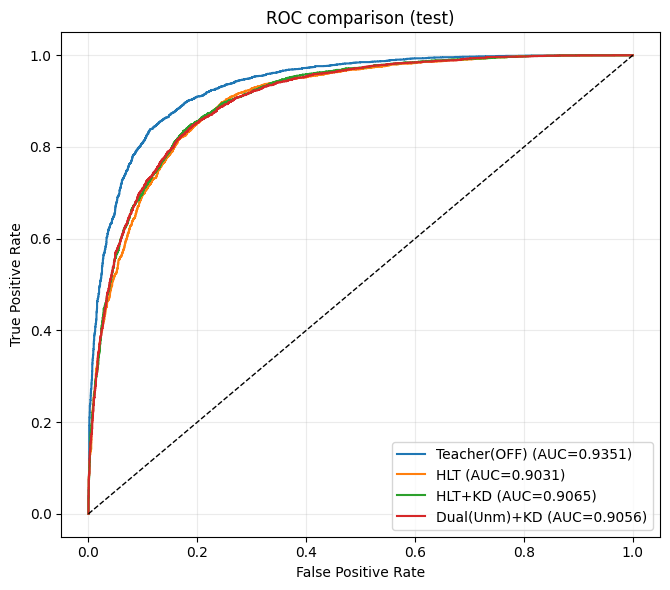

In [12]:
# Downstream models: teacher / HLT baseline / HLT KD / Dual(unmerge) KD

BSt = 512
train_tag_ds = tool.JetTaggerDataset(
    train_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)
val_tag_ds = tool.JetTaggerDataset(
    val_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)
test_tag_ds = tool.JetTaggerDataset(
    test_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)

train_tag_loader = DataLoader(train_tag_ds, batch_size=BSt, shuffle=True, drop_last=True)
val_tag_loader = DataLoader(val_tag_ds, batch_size=BSt)
test_tag_loader = DataLoader(test_tag_ds, batch_size=BSt)

TAGGER_CFG = {
    'input_dim': 4,
    'embed_dim': 128,
    'num_heads': 8,
    'num_layers': 4,
    'ff_dim': 512,
    'dropout': 0.1,
}
TRAIN_CFG = {
    'epochs': 30,
    'lr': 5e-4,
    'weight_decay': 1e-5,
    'patience': 5,
    'grad_clip': 1.0,
}
KD_CFG = {
    'temperature': 3.0,
    'alpha_kd': 0.5,
    'alpha_attn': 0.0,
}

ckpt_dir = CONFIG['io']['ckpt_dir']
load_ckpt = CONFIG['io'].get('load_ckpt', None)
ckpt_teacher = os.path.join(ckpt_dir, 'tagger_teacher_off.pt')
ckpt_hlt = os.path.join(ckpt_dir, 'tagger_hlt_baseline.pt')
ckpt_hlt_kd = os.path.join(ckpt_dir, 'tagger_hlt_kd.pt')
ckpt_dual_kd = os.path.join(ckpt_dir, 'tagger_dual_unm_kd.pt')

# 1) Teacher (offline)
teacher = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_teacher) and load_ckpt is not None:
    print('Loading teacher:', ckpt_teacher)
    tool.load_checkpoint(teacher, ckpt_teacher, map_location=device)
else:
    best, _ = tool.train_teacher(teacher, train_tag_loader, val_tag_loader, device, **TRAIN_CFG)
    tool.save_checkpoint(teacher, ckpt_teacher, extra={'best_val_auc': float(best)})

# 2) HLT baseline
hlt_base = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_hlt) and load_ckpt is not None:
    print('Loading HLT baseline:', ckpt_hlt)
    tool.load_checkpoint(hlt_base, ckpt_hlt, map_location=device)
else:
    best, _ = tool.train_hlt_baseline(hlt_base, train_tag_loader, val_tag_loader, device, **TRAIN_CFG)
    tool.save_checkpoint(hlt_base, ckpt_hlt, extra={'best_val_auc': float(best)})

# 3) HLT KD student
hlt_kd = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_hlt_kd) and load_ckpt is not None:
    print('Loading HLT KD:', ckpt_hlt_kd)
    tool.load_checkpoint(hlt_kd, ckpt_hlt_kd, map_location=device)
else:
    best, _ = tool.train_hlt_kd(
        hlt_kd,
        teacher,
        train_tag_loader,
        val_tag_loader,
        device,
        **TRAIN_CFG,
        **KD_CFG,
    )
    tool.save_checkpoint(hlt_kd, ckpt_hlt_kd, extra={'best_val_auc': float(best)})

# 4) Dual-view (HLT + Unmerged) KD student

dual_kd = DualViewTagger(**TAGGER_CFG, fuse_heads=8).to(device)
if os.path.exists(ckpt_dual_kd) and load_ckpt is not None:
    print('Loading Dual KD:', ckpt_dual_kd)
    tool.load_checkpoint(dual_kd, ckpt_dual_kd, map_location=device)
else:
    best, _ = tool.train_dual_student_kd(
        dual_kd,
        teacher,
        train_tag_loader,
        val_tag_loader,
        device,
        **TRAIN_CFG,
        **KD_CFG,
    )
    tool.save_checkpoint(dual_kd, ckpt_dual_kd, extra={'best_val_auc': float(best)})

# Evaluate AUC on TEST
auc_teacher = tool.eval_auc_logits(teacher, test_tag_loader, device, kind='teacher')
auc_hlt = tool.eval_auc_logits(hlt_base, test_tag_loader, device, kind='hlt')
auc_hlt_kd = tool.eval_auc_logits(hlt_kd, test_tag_loader, device, kind='hlt')
auc_dual_kd = tool.eval_auc_logits(dual_kd, test_tag_loader, device, kind='dual')

print('TEST AUCs:')
print('  Teacher(OFF):', auc_teacher)
print('  HLT baseline:', auc_hlt)
print('  HLT + KD    :', auc_hlt_kd)
print('  Dual(Unm)+KD:', auc_dual_kd)

# Plot ROC curves (one figure)

curves = {}

from sklearn.metrics import roc_curve  # local import for notebook

p, y_true = tool.collect_probs_logits(teacher, test_tag_loader, device, kind='teacher')
fpr, tpr, _ = roc_curve(y_true, p)
curves['Teacher(OFF)'] = (fpr, tpr, auc_teacher)

p, y_true = tool.collect_probs_logits(hlt_base, test_tag_loader, device, kind='hlt')
fpr, tpr, _ = roc_curve(y_true, p)
curves['HLT'] = (fpr, tpr, auc_hlt)

p, y_true = tool.collect_probs_logits(hlt_kd, test_tag_loader, device, kind='hlt')
fpr, tpr, _ = roc_curve(y_true, p)
curves['HLT+KD'] = (fpr, tpr, auc_hlt_kd)

p, y_true = tool.collect_probs_logits(dual_kd, test_tag_loader, device, kind='dual')
fpr, tpr, _ = roc_curve(y_true, p)
curves['Dual(Unm)+KD'] = (fpr, tpr, auc_dual_kd)

fig_path = os.path.join(CONFIG['io']['fig_dir'], 'roc_comparison.png')
tool.plot_roc_curves(curves, title='ROC comparison (test)', save_path=fig_path, dpi=160)